In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("RETAIL PULSE notebook is ready.")

RETAIL PULSE notebook is ready.


In [4]:
import sys

print(sys.executable)

c:\Users\91756\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
import pandas as pd

data_path = "../data/MUC01_Retail_Sales_Dataset 1.csv"

df = pd.read_csv(data_path)

print("RETAIL PULSE dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

RETAIL PULSE dataset loaded successfully.
Rows    : 107,836
Columns : 10


In [6]:
df.head(10).style \
    .set_caption("RETAIL PULSE — Sample Retail Sales Data") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.460000,5843.370000,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.060000,11598.060000,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.370000,15493.600000,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.280000,9351.650000,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.140000,1917.140000,0
5,TXN000006,2026-01-01,S01,Vijayawada,Apparel,Formal Shirt,2,936.280000,1498.050000,20
6,TXN000007,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1005.410000,1910.280000,5
7,TXN000008,2026-01-01,S01,Vijayawada,Apparel,Kurta,3,2728.180000,8184.540000,0
8,TXN000009,2026-01-01,S01,Vijayawada,Apparel,T-Shirt,2,1388.800000,2777.600000,0
9,TXN000010,2026-01-01,S01,Vijayawada,Apparel,Jeans,2,3363.080000,6053.540000,10


In [7]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

column_summary.style \
    .set_caption("RETAIL PULSE — Column Summary") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Column,Data Type,Missing Values,Unique Values
0,transaction_id,str,0,107836
1,date,str,0,181
2,store_id,str,0,12
3,store_city,str,0,6
4,category,str,0,5
5,product_name,str,0,25
6,units_sold,int64,0,12
7,unit_price,float64,0,76071
8,revenue,float64,0,91184
9,discount_pct,int64,0,5


In [8]:
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values
})

missing_summary.style \
    .set_caption("RETAIL PULSE — Missing Value Check") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Column,Missing Values,Missing %
0,transaction_id,0,0.000000
1,date,0,0.000000
2,store_id,0,0.000000
3,store_city,0,0.000000
4,category,0,0.000000
5,product_name,0,0.000000
6,units_sold,0,0.000000
7,unit_price,0,0.000000
8,revenue,0,0.000000
9,discount_pct,0,0.000000


In [9]:
duplicate_count = df.duplicated().sum()

print(f"Total records      : {len(df):,}")
print(f"Duplicate records  : {duplicate_count:,}")
print(f"Unique records     : {len(df) - duplicate_count:,}")

Total records      : 107,836
Duplicate records  : 0
Unique records     : 107,836


In [10]:
numeric_summary = df.describe().T

numeric_summary.style \
    .set_caption("RETAIL PULSE — Numerical Data Summary") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,count,mean,std,min,25%,50%,75%,max
units_sold,107836.000000,2.583488,1.471616,1.000000,1.000000,2.000000,3.000000,13.000000
unit_price,107836.000000,1778.097787,5053.631792,50.020000,274.827500,488.450000,1039.522500,44990.140000
revenue,107836.000000,4263.920924,14243.244169,40.040000,467.772500,1034.615000,2473.335000,355090.880000
discount_pct,107836.000000,7.228152,6.730445,0.000000,0.000000,5.000000,10.000000,20.000000


In [11]:
print("========== RETAIL PULSE DATASET OVERVIEW ==========")
print(f"Total Records : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")
print(f"Duplicate Rows: {df.duplicated().sum():,}")
print(f"Missing Cells : {df.isnull().sum().sum():,}")
print("===================================================")

========== RETAIL PULSE DATASET OVERVIEW ==========
Total Records : 107,836
Total Columns : 10
Duplicate Rows: 0
Missing Cells : 0


In [14]:
# RETAIL PULSE — Unique values in categorical columns

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(f"Unique values: {df[col].nunique():,}")
    print(df[col].value_counts().head(10))


--- transaction_id ---
Unique values: 107,836
transaction_id
TXN000001    1
TXN000002    1
TXN000003    1
TXN000004    1
TXN000005    1
TXN000006    1
TXN000007    1
TXN000008    1
TXN000009    1
TXN000010    1
Name: count, dtype: int64

--- date ---
Unique values: 181
date
2026-06-20    859
2026-04-18    849
2026-05-09    845
2026-02-07    841
2026-06-06    830
2026-03-28    825
2026-01-24    810
2026-03-07    810
2026-06-27    808
2026-02-21    807
Name: count, dtype: int64

--- store_id ---
Unique values: 12
store_id
S01    13270
S03    12330
S07    11308
S06    10488
S02     9813
S04     9412
S08     8641
S09     8355
S11     7738
S05     5990
Name: count, dtype: int64

--- store_city ---
Unique values: 6
store_city
Vijayawada     23083
Guntur         21742
Tirupati       19949
Rajahmundry    16478
Nellore        13883
Kakinada       12701
Name: count, dtype: int64

--- category ---
Unique values: 5
category
Grocery           54185
Personal Care     25947
Apparel           15301
H

C:\Users\91756\AppData\Local\Temp\ipykernel_18900\1973178461.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


## Task 1 — Business Observations

- The dataset contains **107,836 retail transaction records** across **10 columns**,
  providing transaction-level data for the required retail analysis.

- The dataset contains **no missing values**, so all available records can be
  used for the planned analysis without missing-data treatment.

- The dataset contains **no duplicate records**, indicating that duplicate
  transactions do not need to be removed at this stage.

- The available transaction data provides the basis for analysing **category
  revenue trends, product performance, discount effectiveness, and sales
  patterns over time**.

- These initial checks confirm that the dataset is suitable for proceeding
  with the planned Category Intelligence analysis.
  

# Task 2 — Category Revenue Trend

### Objective

Analyse the monthly revenue trend for all product categories to identify
categories showing decline, growth, or consistent performance.

### Business Questions

1. Which category shows the steepest decline?
2. Which category is the most consistent?
3. What do these trends imply for the Category Manager?


In [15]:
# Task 2 — Prepare date information

df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M")

print("Date preparation completed.")
print(f"Analysis period: {df['date'].min().date()} to {df['date'].max().date()}")

Date preparation completed.
Analysis period: 2026-01-01 to 2026-06-30


In [16]:
# Calculate monthly revenue by category

monthly_category_revenue = (
    df.groupby(["month", "category"])["revenue"]
      .sum()
      .reset_index()
)

monthly_category_revenue.head(10)

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


In [17]:
# Pivot table for category comparison

monthly_category_table = (
    monthly_category_revenue
    .pivot(index="month", columns="category", values="revenue")
    .reset_index()
)

monthly_category_table

category,month,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
0,2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
1,2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2,2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
3,2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
4,2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
5,2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


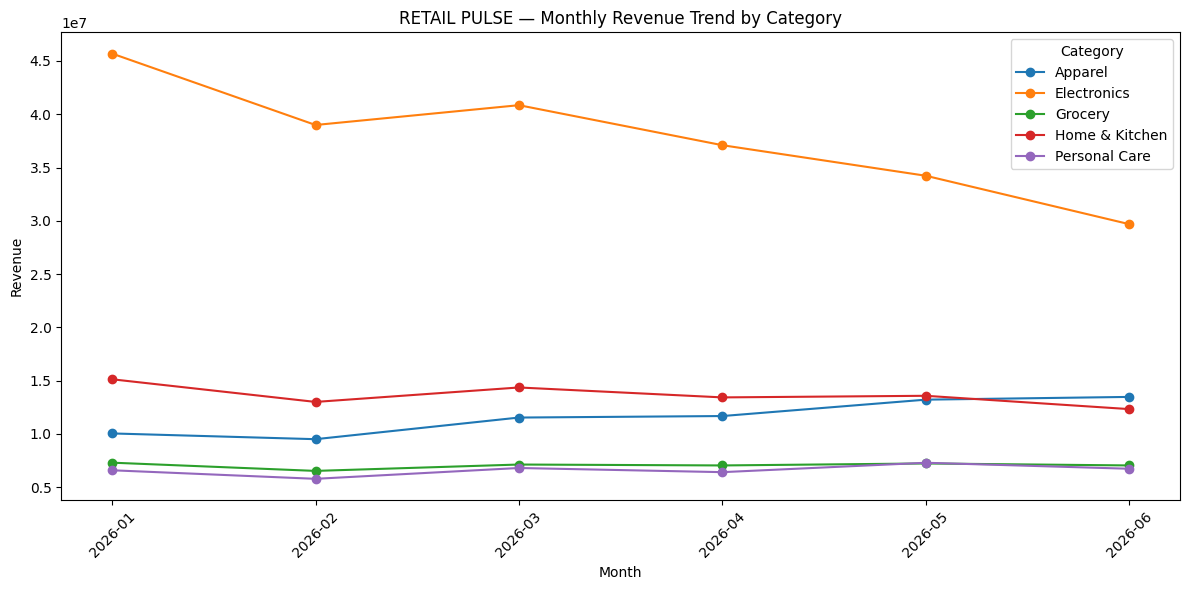

In [18]:
# Task 2 — Monthly revenue trend by category

plt.figure(figsize=(12, 6))

for category in monthly_category_table.columns[1:]:
    plt.plot(
        monthly_category_table["month"].astype(str),
        monthly_category_table[category],
        marker="o",
        label=category
    )

plt.title("RETAIL PULSE — Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()

plt.show()

In [19]:
# Task 2 — Measure category performance change

category_change = pd.DataFrame({
    "Starting Revenue": monthly_category_table.iloc[0, 1:].values,
    "Ending Revenue": monthly_category_table.iloc[-1, 1:].values
}, index=monthly_category_table.columns[1:])

category_change["Absolute Change"] = (
    category_change["Ending Revenue"] -
    category_change["Starting Revenue"]
)

category_change["Percentage Change"] = (
    category_change["Absolute Change"] /
    category_change["Starting Revenue"]
) * 100

category_change = category_change.sort_values(
    "Percentage Change"
)

category_change.style.format({
    "Starting Revenue": "{:,.2f}",
    "Ending Revenue": "{:,.2f}",
    "Absolute Change": "{:,.2f}",
    "Percentage Change": "{:.2f}%"
}).set_caption("RETAIL PULSE — Category Revenue Change")

,Starting Revenue,Ending Revenue,Absolute Change,Percentage Change
category,,,,
Electronics,"45,686,596.63","29,686,824.81","-15,999,771.82",-35.02%
Home & Kitchen,"15,130,871.54","12,333,283.07","-2,797,588.47",-18.49%
Grocery,"7,307,011.34","7,047,719.23","-259,292.11",-3.55%
Personal Care,"6,593,734.81","6,737,354.12","143,619.31",2.18%
Apparel,"10,049,916.78","13,476,952.88","3,427,036.10",34.10%


In [20]:
# Task 2 — Measure monthly revenue consistency

category_consistency = monthly_category_table.iloc[:, 1:].std().sort_values()

consistency_table = pd.DataFrame({
    "Monthly Revenue Std. Dev.": category_consistency
})

consistency_table.style.format({
    "Monthly Revenue Std. Dev.": "{:,.2f}"
}).set_caption(
    "RETAIL PULSE — Category Revenue Consistency"
)

,Monthly Revenue Std. Dev.
category,
Grocery,"272,605.89"
Personal Care,"496,981.44"
Home & Kitchen,"989,958.26"
Apparel,"1,607,520.40"
Electronics,"5,513,100.79"


In [21]:
# Task 2 — Identify steepest decline and most consistent category

steepest_decline = category_change["Percentage Change"].idxmin()
most_consistent = category_consistency.idxmin()

print(f"Steepest decline   : {steepest_decline}")
print(f"Most consistent    : {most_consistent}")

Steepest decline   : Electronics
Most consistent    : Grocery


## Task 2 — Business Insight

### Steepest Decline — Electronics

**Electronics** shows the steepest revenue decline over the analysis
period based on the percentage change between the first and last months.

This indicates that Electronics requires closer attention from the Category
Manager during the supplier review. The decline should be investigated to
understand whether it is related to product-level performance, pricing,
discounting, demand changes, or other factors.

### Most Consistent — Grocery

**Grocery** shows the most consistent monthly revenue performance based on
the lowest standard deviation among the categories.

This indicates relatively stable revenue performance throughout the
analysis period and provides a useful benchmark when comparing the other
categories.

### Category Manager Implication

The Category Manager should prioritize **Electronics** for further
investigation because of its declining revenue trend, while **Grocery**
can be considered a stable category whose performance should be maintained
and potentially used as a benchmark.

In [28]:
# Task 3 — Revenue by product

product_revenue = (
    df.groupby("product_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_revenue.head()

top_5_products = product_revenue.head(5)

top_5_products

bottom_5_products = product_revenue.tail(5).sort_values()

bottom_5_products


product_name
Sunscreen      7593863.45
Toothpaste     7768812.48
Face Wash      8010977.89
Body Lotion    8106578.00
Shampoo        8168328.26
Name: revenue, dtype: float64

In [25]:
top_bottom_products = pd.concat([
    top_5_products.rename("Revenue").to_frame().assign(Performance="Top 5"),
    bottom_5_products.rename("Revenue").to_frame().assign(Performance="Bottom 5")
])

top_bottom_products = top_bottom_products.reset_index()
top_bottom_products.columns = ["Product", "Revenue", "Performance"]

top_bottom_products.style \
    .format({"Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Top & Bottom Products by Revenue")

,Product,Revenue,Performance
0,Headphones,"₹47,696,053.99",Top 5
1,Laptop,"₹46,551,078.39",Top 5
2,Mobile Phone,"₹45,654,037.41",Top 5
3,Tablet,"₹44,744,388.93",Top 5
4,Smart TV,"₹41,882,166.21",Top 5
5,Sunscreen,"₹7,593,863.45",Bottom 5
6,Toothpaste,"₹7,768,812.48",Bottom 5
7,Face Wash,"₹8,010,977.89",Bottom 5
8,Body Lotion,"₹8,106,578.00",Bottom 5
9,Shampoo,"₹8,168,328.26",Bottom 5


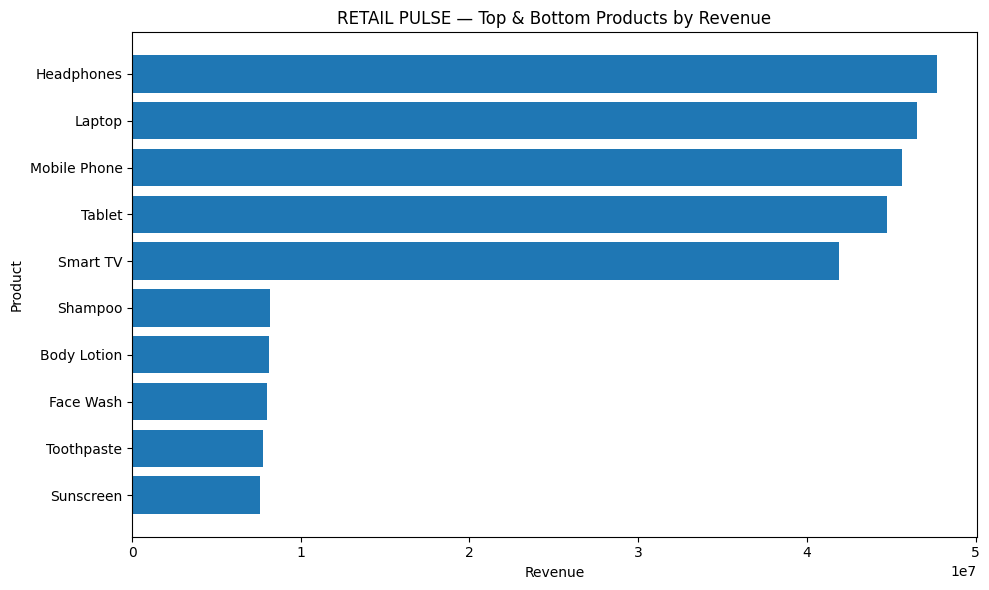

In [29]:
# Task 3 — Top and Bottom Product Revenue

plot_data = top_bottom_products.sort_values("Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Product"],
    plot_data["Revenue"]
)

plt.title("RETAIL PULSE — Top & Bottom Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [44]:
# Task 3 — Top 2 and Bottom 2 Products for Each Category

category_product_revenue = (
    df.groupby(["category", "product_name"], as_index=False)["revenue"]
      .sum()
)

# Rank products within each category
category_product_revenue["Rank"] = (
    category_product_revenue
    .groupby("category")["revenue"]
    .rank(method="first", ascending=False)
)

# Total number of products in each category
category_product_revenue["Total Products"] = (
    category_product_revenue
    .groupby("category")["product_name"]
    .transform("count")
)

# Select top 2 and bottom 2
top_products = category_product_revenue[
    category_product_revenue["Rank"] <= 2
].copy()

bottom_products = category_product_revenue[
    category_product_revenue["Rank"] >
    category_product_revenue["Total Products"] - 2
].copy()

top_products["Performance"] = "Top 2"
bottom_products["Performance"] = "Bottom 2"

top_bottom_by_category = pd.concat(
    [top_products, bottom_products],
    ignore_index=True
)

top_bottom_by_category = top_bottom_by_category[
    ["category", "product_name", "revenue", "Performance"]
].sort_values(
    ["category", "Performance", "revenue"],
    ascending=[True, True, False]
).reset_index(drop=True)

top_bottom_by_category.style \
    .format({"revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Top 2 & Bottom 2 Products by Category") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,category,product_name,revenue,Performance
0,Apparel,Formal Shirt,"₹13,748,976.91",Bottom 2
1,Apparel,Kurta,"₹13,606,747.03",Bottom 2
2,Apparel,Saree,"₹14,161,864.63",Top 2
3,Apparel,T-Shirt,"₹14,099,251.65",Top 2
4,Electronics,Tablet,"₹44,744,388.93",Bottom 2
5,Electronics,Smart TV,"₹41,882,166.21",Bottom 2
6,Electronics,Headphones,"₹47,696,053.99",Top 2
7,Electronics,Laptop,"₹46,551,078.39",Top 2
8,Grocery,Oil (1L),"₹8,431,630.01",Bottom 2
9,Grocery,Sugar (1kg),"₹8,377,786.05",Bottom 2


In [47]:
# Task 3 — Identify category drag from bottom-performing products

category_summary = (
    top_bottom_by_category
    .groupby(["category", "Performance"])["revenue"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

category_summary["Top 2 Revenue"] = category_summary.get("Top 2", 0)
category_summary["Bottom 2 Revenue"] = category_summary.get("Bottom 2", 0)

category_summary = category_summary[
    ["category", "Top 2 Revenue", "Bottom 2 Revenue"]
]

category_summary.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Category Top/Bottom Product Contribution")
    
    # Compare the strength of top and bottom products within each category

category_summary["Bottom-to-Top Revenue Ratio"] = (
    category_summary["Bottom 2 Revenue"] /
    category_summary["Top 2 Revenue"]
) * 100

category_summary.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}",
        "Bottom-to-Top Revenue Ratio": "{:.2f}%"
    }) \
    .set_caption("RETAIL PULSE — Category Product Performance Comparison")

Performance,category,Top 2 Revenue,Bottom 2 Revenue,Bottom-to-Top Revenue Ratio
0,Apparel,"₹28,261,116.28","₹27,355,723.94",96.80%
1,Electronics,"₹94,247,132.38","₹86,626,555.14",91.91%
2,Grocery,"₹17,050,475.50","₹16,809,416.06",98.59%
3,Home & Kitchen,"₹33,579,789.89","₹31,968,171.56",95.20%
4,Personal Care,"₹16,274,906.26","₹15,362,675.93",94.39%


In [51]:
# Task 3 — Identify the category with the largest Top 2 vs Bottom 2 gap

category_summary["Performance Gap"] = (
    category_summary["Top 2 Revenue"] -
    category_summary["Bottom 2 Revenue"]
)

supplier_review_table = (
    category_summary
    .sort_values("Performance Gap", ascending=False)
    .reset_index(drop=True)
)

supplier_review_table.style \
    .format({
        "Top 2 Revenue": "₹{:,.2f}",
        "Bottom 2 Revenue": "₹{:,.2f}",
        "Bottom-to-Top Revenue Ratio": "{:.2f}%",
        "Performance Gap": "₹{:,.2f}"
    }) \
    .set_caption("RETAIL PULSE — Supplier Review Category Comparison")


Performance,category,Top 2 Revenue,Bottom 2 Revenue,Bottom-to-Top Revenue Ratio,Performance Gap
0,Electronics,"₹94,247,132.38","₹86,626,555.14",91.91%,"₹7,620,577.24"
1,Home & Kitchen,"₹33,579,789.89","₹31,968,171.56",95.20%,"₹1,611,618.33"
2,Personal Care,"₹16,274,906.26","₹15,362,675.93",94.39%,"₹912,230.33"
3,Apparel,"₹28,261,116.28","₹27,355,723.94",96.80%,"₹905,392.34"
4,Grocery,"₹17,050,475.50","₹16,809,416.06",98.59%,"₹241,059.44"


In [52]:
supplier_review_category = supplier_review_table.iloc[0]["category"]

print(f"Category requiring supplier review: {supplier_review_category}")

Category requiring supplier review: Electronics


## Task 3 — Supplier Review Decision

### Recommended Category for Review

**[CATEGORY]** should receive closer attention during the supplier review.

### Why?

The category shows the largest revenue gap between its top-performing and
bottom-performing products based on the category-level Top 2 and Bottom 2
analysis.

This indicates a significant difference in product contribution within the
category and provides a clear area for supplier discussion.

### Recommended Discussion

The Category Manager should investigate the reasons behind the weaker
products, including demand, pricing, discounting, product positioning, and
assortment decisions.

The objective should be to determine whether the lower-performing products
can be improved, repositioned, replaced, or better supported.

In [34]:
# Task 4 — Category Revenue Performance

category_revenue = (
    df.groupby("category", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
      .reset_index(drop=True)
)

category_revenue.index = category_revenue.index + 1

category_revenue.columns = ["Category", "Total Revenue"]

category_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Category Revenue Performance") \
    .set_properties(**{
        "text-align": "left",
        "font-size": "12pt"
    }) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

,Category,Total Revenue
1,Electronics,"₹226,527,724.93"
2,Home & Kitchen,"₹81,845,721.33"
3,Apparel,"₹69,479,589.68"
4,Grocery,"₹42,302,580.76"
5,Personal Care,"₹39,648,560.08"


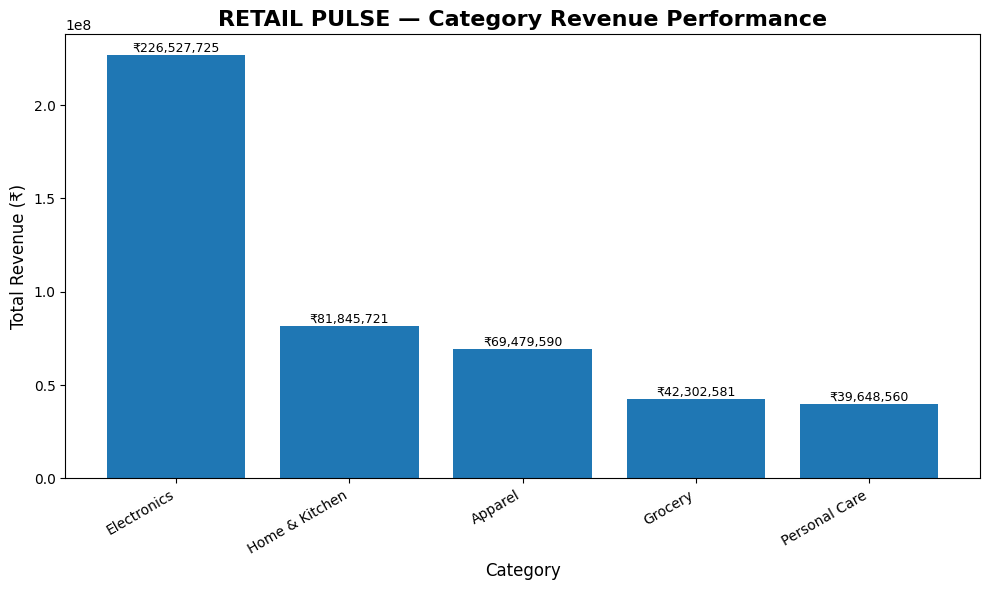

In [35]:
# Task 4 — Category Revenue Comparison

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_revenue["Category"],
    category_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Category Revenue Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)

plt.xticks(rotation=30, ha="right")

# Add revenue labels above bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [55]:
# Task 4 — Discount Effectiveness

discount_summary = (
    df.groupby("discount_pct", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Average_Revenue=("revenue", "mean"),
          Transactions=("revenue", "count")
      )
      .sort_values("discount_pct")
      .reset_index(drop=True)
)

discount_summary.style \
    .format({
        "discount_pct": "{:.0%}",
        "Total_Revenue": "₹{:,.2f}",
        "Average_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Revenue Performance by Discount") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,discount_pct,Total_Revenue,Average_Revenue,Transactions
0,0%,"₹168,838,182.82","₹4,685.65","36,033"
1,500%,"₹102,953,836.52","₹4,303.73","23,922"
2,1000%,"₹95,372,036.10","₹4,005.55","23,810"
3,1500%,"₹48,565,477.21","₹4,069.16","11,935"
4,2000%,"₹44,074,644.13","₹3,631.73","12,136"


## Task 4 — Business Insight

### Discount Effectiveness

The analysis compares revenue performance across different discount levels.

### Category Manager Implication

Discount levels should be evaluated based on their relationship with revenue and transaction volume. Higher discounts should not be assumed to improve performance unless the data shows a clear revenue benefit.

In [64]:
# Task 5 — Identify the most interesting category

category_summary.sort_values(
    "Total_Revenue",
    ascending=False
).style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Category Performance for Task 5")

,category,Total_Revenue,Transactions,Units_Sold
0,Electronics,"₹226,527,724.93","4,015","10,372"
1,Home & Kitchen,"₹81,845,721.33","8,388","21,658"
2,Apparel,"₹69,479,589.68","15,301","39,456"
3,Grocery,"₹42,302,580.76","54,185","140,326"
4,Personal Care,"₹39,648,560.08","25,947","66,781"


In [36]:
# Task 5 — Prepare time-based features

df["day_of_week"] = df["date"].dt.day_name()
df["month_name"] = df["date"].dt.month_name()

print("Time-based features created successfully.")

Time-based features created successfully.


In [37]:
# Revenue by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = (
    df.groupby("day_of_week")["revenue"]
      .sum()
      .reindex(day_order)
      .reset_index()
)

day_revenue.columns = ["Day", "Total Revenue"]

day_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Revenue by Day of Week") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day,Total Revenue
0,Monday,"₹52,315,665.05"
1,Tuesday,"₹53,407,372.28"
2,Wednesday,"₹55,702,931.10"
3,Thursday,"₹58,382,818.55"
4,Friday,"₹68,213,909.13"
5,Saturday,"₹91,613,741.57"
6,Sunday,"₹80,167,739.10"


In [38]:
# Revenue by month

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June"
]

month_revenue = (
    df.groupby("month_name")["revenue"]
      .sum()
      .reindex(month_order)
      .reset_index()
)

month_revenue.columns = ["Month", "Total Revenue"]

month_revenue.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Revenue by Month") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Month,Total Revenue
0,January,"₹84,768,131.10"
1,February,"₹73,833,666.23"
2,March,"₹80,689,884.84"
3,April,"₹75,670,487.12"
4,May,"₹75,559,873.38"
5,June,"₹69,282,134.11"


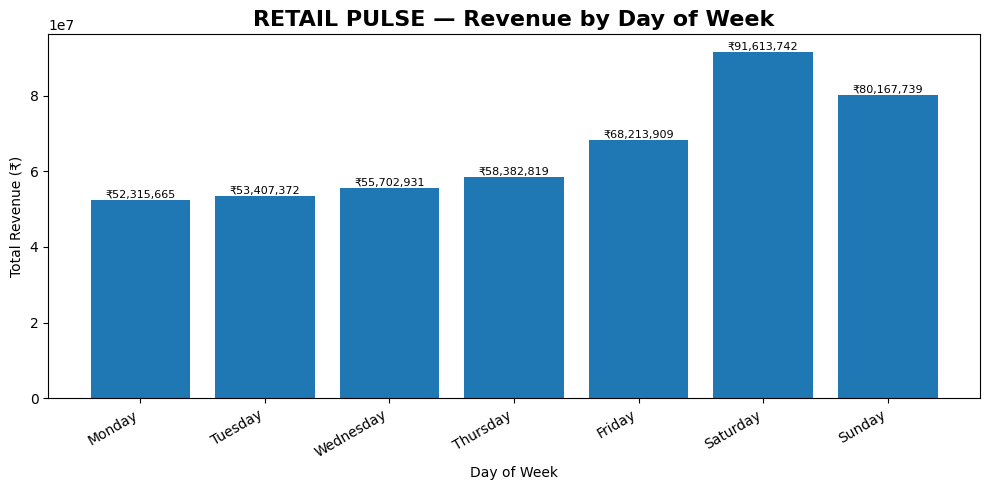

In [39]:
# Revenue pattern by day of week

plt.figure(figsize=(10, 5))

bars = plt.bar(
    day_revenue["Day"],
    day_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Revenue by Day of Week",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

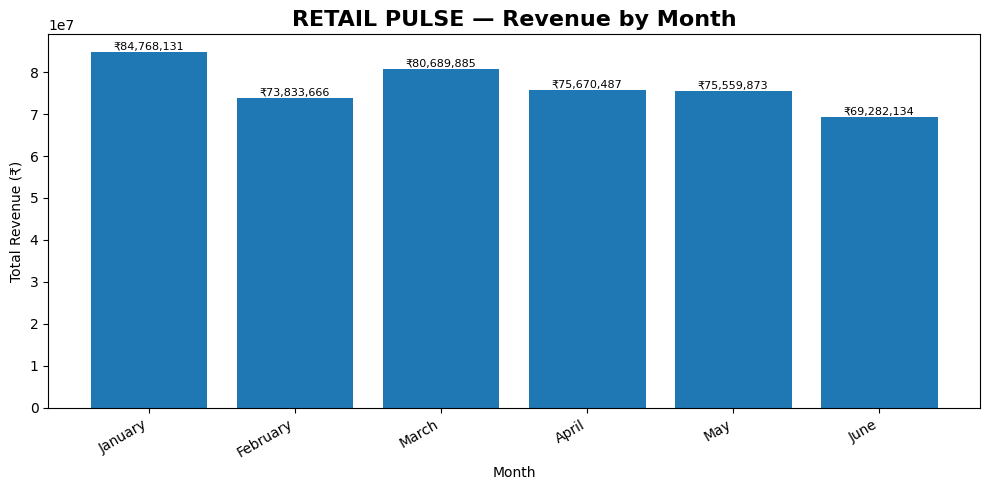

In [63]:
# Revenue pattern by month

plt.figure(figsize=(10, 5))

bars = plt.bar(
    month_revenue["Month"],
    month_revenue["Total Revenue"]
)

plt.title(
    "RETAIL PULSE — Revenue by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [61]:
# Task 5 — Average Daily Revenue by Day of Week

daily_revenue = (
    df.groupby(["date", "day_of_week"], as_index=False)["revenue"]
      .sum()
)

day_pattern = (
    daily_revenue
    .groupby("day_of_week", as_index=False)["revenue"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_pattern["day_of_week"] = pd.Categorical(
    day_pattern["day_of_week"],
    categories=day_order,
    ordered=True
)

day_pattern = (
    day_pattern
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

day_pattern.columns = [
    "Day of Week",
    "Average Daily Revenue"
]

day_pattern.style \
    .format({"Average Daily Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Average Daily Revenue by Day") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day of Week,Average Daily Revenue
0,Monday,"₹2,012,140.96"
1,Tuesday,"₹2,054,129.70"
2,Wednesday,"₹2,228,117.24"
3,Thursday,"₹2,245,493.02"
4,Friday,"₹2,623,611.89"
5,Saturday,"₹3,523,605.44"
6,Sunday,"₹3,083,374.58"


In [65]:
# Task 5 — Electronics Category Time Pattern

electronics_df = df[df["category"] == "Electronics"].copy()

# Daily revenue
electronics_daily_revenue = (
    electronics_df
    .groupby(["date", "day_of_week"], as_index=False)["revenue"]
    .sum()
)

# Average daily revenue by day of week
electronics_day_pattern = (
    electronics_daily_revenue
    .groupby("day_of_week", as_index=False)["revenue"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

electronics_day_pattern["day_of_week"] = pd.Categorical(
    electronics_day_pattern["day_of_week"],
    categories=day_order,
    ordered=True
)

electronics_day_pattern = (
    electronics_day_pattern
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

electronics_day_pattern.columns = [
    "Day of Week",
    "Average Daily Revenue"
]

electronics_day_pattern.style \
    .format({"Average Daily Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Electronics Average Daily Revenue") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Day of Week,Average Daily Revenue
0,Monday,"₹970,975.52"
1,Tuesday,"₹975,432.75"
2,Wednesday,"₹1,111,579.33"
3,Thursday,"₹1,061,517.79"
4,Friday,"₹1,291,063.65"
5,Saturday,"₹1,786,658.45"
6,Sunday,"₹1,558,130.36"


In [66]:
# Task 5 — Electronics Total Revenue by Month

electronics_month_pattern = (
    electronics_df
    .groupby("month", as_index=False)["revenue"]
    .sum()
    .sort_values("month")
    .reset_index(drop=True)
)

electronics_month_pattern.columns = [
    "Month",
    "Total Revenue"
]

electronics_month_pattern.style \
    .format({"Total Revenue": "₹{:,.2f}"}) \
    .set_caption("RETAIL PULSE — Electronics Monthly Revenue") \
    .set_properties(**{
        "text-align": "left",
        "padding": "6px"
    })

,Month,Total Revenue
0,2026-01,"₹45,686,596.63"
1,2026-02,"₹38,988,602.50"
2,2026-03,"₹40,846,509.47"
3,2026-04,"₹37,092,265.09"
4,2026-05,"₹34,226,926.43"
5,2026-06,"₹29,686,824.81"


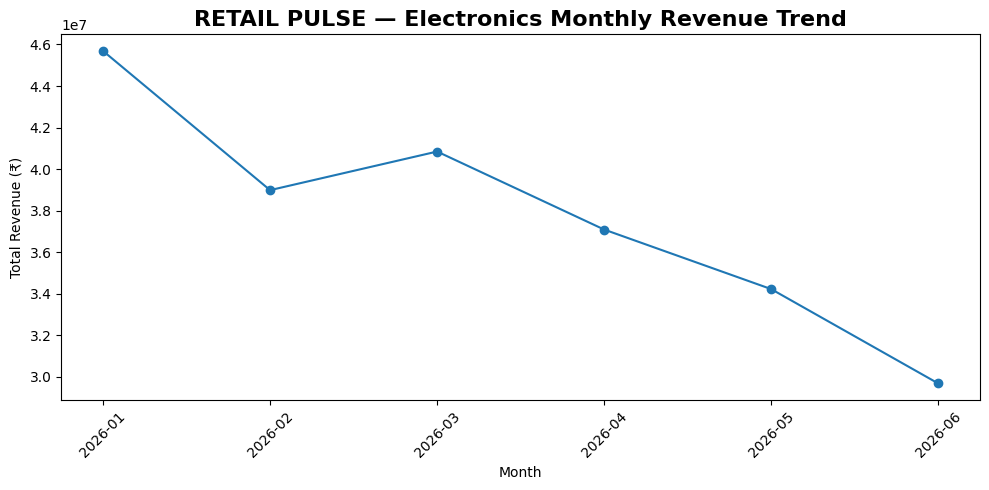

In [68]:
# Electronics Monthly Revenue Trend

plt.figure(figsize=(10, 5))

plt.plot(
    electronics_month_pattern["Month"].astype(str),
    electronics_month_pattern["Total Revenue"],
    marker="o"
)

plt.title(
    "RETAIL PULSE — Electronics Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 5 — Electronics Monthly Revenue

This analysis examines the monthly revenue pattern of the Electronics category to identify stronger and weaker revenue periods.

## Task 5 — Business Insight

### Overall Time Pattern

The day-of-week analysis identifies the strongest and weakest average daily revenue periods, while the monthly analysis highlights periods of higher and lower overall sales.

### Electronics Time Pattern

Electronics was selected as the most interesting category because it is the highest-revenue category. Its day-of-week and monthly patterns help identify when this category contributes most strongly to sales.

### Category Manager Implication

The identified high-performing days and months can be used to support sales planning, inventory availability, and promotional decisions. Lower-performing periods can be examined for potential improvement opportunities.

In [69]:
# Task 5 — Key Time-Based Insights

best_day = day_pattern.loc[
    day_pattern["Average Daily Revenue"].idxmax()
]

worst_day = day_pattern.loc[
    day_pattern["Average Daily Revenue"].idxmin()
]

best_month = month_pattern.loc[
    month_pattern["Total Revenue"].idxmax()
]

worst_month = month_pattern.loc[
    month_pattern["Total Revenue"].idxmin()
]

electronics_best_day = electronics_day_pattern.loc[
    electronics_day_pattern["Average Daily Revenue"].idxmax()
]

electronics_worst_day = electronics_day_pattern.loc[
    electronics_day_pattern["Average Daily Revenue"].idxmin()
]

electronics_best_month = electronics_month_pattern.loc[
    electronics_month_pattern["Total Revenue"].idxmax()
]

electronics_worst_month = electronics_month_pattern.loc[
    electronics_month_pattern["Total Revenue"].idxmin()
]

print("========== RETAIL PULSE — TASK 5 KEY INSIGHTS ==========")

print(f"Overall best day       : {best_day['Day of Week']}")
print(f"Overall worst day      : {worst_day['Day of Week']}")

print(f"Overall best month     : {best_month['Month']}")
print(f"Overall worst month    : {worst_month['Month']}")

print()
print("---------- ELECTRONICS ----------")

print(f"Best Electronics day   : {electronics_best_day['Day of Week']}")
print(f"Worst Electronics day  : {electronics_worst_day['Day of Week']}")

print(f"Best Electronics month : {electronics_best_month['Month']}")
print(f"Worst Electronics month: {electronics_worst_month['Month']}")

print("==========================================================")

========== RETAIL PULSE — TASK 5 KEY INSIGHTS ==========
Overall best day       : Saturday
Overall worst day      : Monday
Overall best month     : 2026-01
Overall worst month    : 2026-06

---------- ELECTRONICS ----------
Best Electronics day   : Saturday
Worst Electronics day  : Monday
Best Electronics month : 2026-01
Worst Electronics month: 2026-06


In [57]:
# Task 6 — Monthly Revenue Trend

monthly_revenue = (
    df.groupby("month", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count")
      )
      .sort_values("month")
      .reset_index(drop=True)
)

monthly_revenue.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Monthly Revenue Trend") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,month,Total_Revenue,Transactions
0,2026-01,"₹84,768,131.10","18,251"
1,2026-02,"₹73,833,666.23","16,475"
2,2026-03,"₹80,689,884.84","18,159"
3,2026-04,"₹75,670,487.12","17,805"
4,2026-05,"₹75,559,873.38","18,904"
5,2026-06,"₹69,282,134.11","18,242"


In [58]:
# Task 7 — Category Performance

category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

category_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Category Performance") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,category,Total_Revenue,Transactions,Units_Sold
0,Electronics,"₹226,527,724.93","4,015","10,372"
1,Home & Kitchen,"₹81,845,721.33","8,388","21,658"
2,Apparel,"₹69,479,589.68","15,301","39,456"
3,Grocery,"₹42,302,580.76","54,185","140,326"
4,Personal Care,"₹39,648,560.08","25,947","66,781"


In [59]:
# Task 8 — Day-of-Week Performance

day_summary = (
    df.groupby("day_of_week", as_index=False)
      .agg(
          Total_Revenue=("revenue", "sum"),
          Transactions=("revenue", "count"),
          Units_Sold=("units_sold", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index(drop=True)
)

day_summary.style \
    .format({
        "Total_Revenue": "₹{:,.2f}",
        "Transactions": "{:,}",
        "Units_Sold": "{:,}"
    }) \
    .set_caption("RETAIL PULSE — Day-of-Week Performance") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
                ("text-align", "right")
            ]
        }
    ])

,day_of_week,Total_Revenue,Transactions,Units_Sold
0,Saturday,"₹91,613,741.57","20,727","53,446"
1,Sunday,"₹80,167,739.10","18,420","47,691"
2,Friday,"₹68,213,909.13","16,028","41,526"
3,Thursday,"₹58,382,818.55","13,720","35,462"
4,Wednesday,"₹55,702,931.10","12,985","33,497"
5,Tuesday,"₹53,407,372.28","13,293","34,093"
6,Monday,"₹52,315,665.05","12,663","32,878"


## Task 8 — Business Insight

### Day-of-Week Performance

- **Highest Revenue Day:** Saturday — ₹91,613,741.57
- **Lowest Revenue Day:** Monday — ₹52,315,665.05

Saturday generates the highest revenue and also records the highest number
of transactions and units sold. Monday shows the lowest revenue among the
days analyzed.

### Category Manager Implication

The stronger weekend performance, particularly on Saturday, indicates an
opportunity to align promotional activity and inventory availability with
higher-demand periods.

The lower Monday performance can be monitored to determine whether targeted
promotions or other interventions could improve sales activity.